# Exploratory Data Analysis

**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

This notebook explores the 42-feature color dataset extracted by `src/processer.py`.
Goals:
- Understand class imbalance and its severity
- Inspect feature distributions and correlations
- Visualize the feature space in 2D (PCA, t-SNE)
- Sanity-check that color features align with type intuitions

In [12]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

cwd = Path.cwd()
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import common

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="darkgrid")

df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL
print(f"Dataset shape: {df.shape}")
print(f"Classes: {df['type1'].nunique()} types, {len(df)} Pokémon")

Dataset shape: (1025, 47)
Classes: 17 types, 1025 Pokémon


## 1. Dataset Overview

In [13]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (1025, 47)

Column dtypes:
id                   int64
name                   str
type1                  str
type2                  str
type1_encoded        int64
dom1_h             float64
dom1_s             float64
dom1_v             float64
dom1_prop          float64
dom2_h             float64
dom2_s             float64
dom2_v             float64
dom2_prop          float64
dom3_h             float64
dom3_s             float64
dom3_v             float64
dom3_prop          float64
dom4_h             float64
dom4_s             float64
dom4_v             float64
dom4_prop          float64
dom5_h             float64
dom5_s             float64
dom5_v             float64
dom5_prop          float64
mean_h_sin         float64
mean_h_cos         float64
mean_s             float64
mean_v             float64
std_s              float64
std_v              float64
std_hue_angular    float64
prop_dark          float64
prop_saturated     float64
color_diversity      int64
hue_bin_0          fl

,id,name,type1,type2,type1_encoded,dom1_h,dom1_s,dom1_v,dom1_prop,dom2_h,...,hue_bin_60,hue_bin_90,hue_bin_120,hue_bin_150,hue_bin_180,hue_bin_210,hue_bin_240,hue_bin_270,hue_bin_300,hue_bin_330
0,1,bulbasaur,grass,poison,9,179.999995,0.623993,0.499350,0.399527,160.199256,...,0.202128,0.000000,0.00000,0.213948,0.399527,0.0,0.0,0.0,0.0,0.035461
1,2,ivysaur,grass,poison,9,174.277795,0.676487,0.636770,0.421335,152.665159,...,0.000000,0.089392,0.13528,0.432658,0.070918,0.0,0.0,0.0,0.0,0.074493
2,3,venusaur,grass,poison,9,169.358350,0.786941,0.597197,0.454822,1.492550,...,0.000000,0.144924,0.00000,0.454822,0.000000,0.0,0.0,0.0,0.0,0.000000


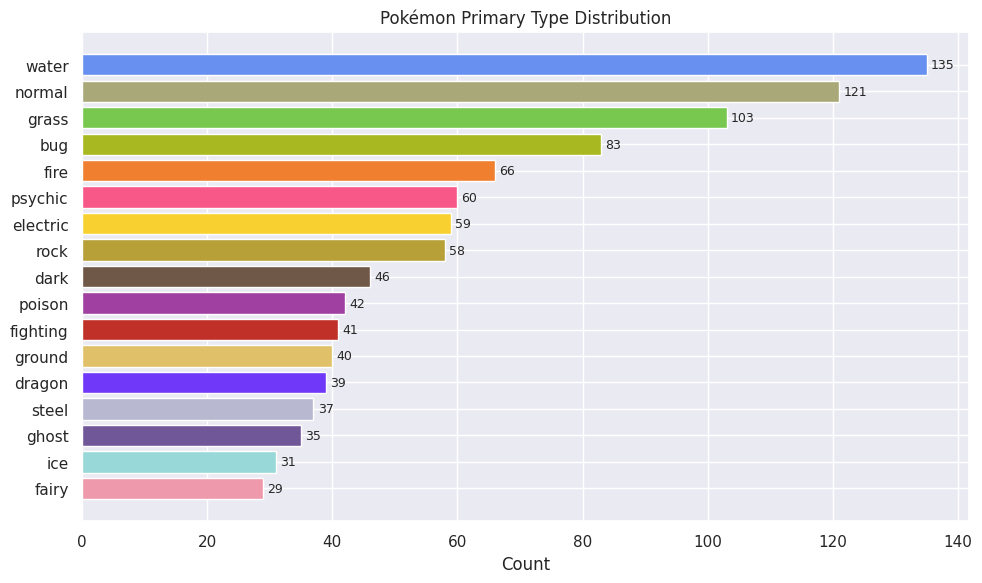


Largest class: water (135)
Smallest class: fairy (29)
Imbalance ratio: 4.7x


In [14]:
counts = df["type1"].value_counts().sort_values()
colors = [common.TYPE_COLORS.get(t, "#888888") for t in counts.index]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Count")
ax.set_title("Pokémon Primary Type Distribution")
plt.tight_layout()
plt.show()
print(f"\nLargest class: {counts.index[-1]} ({counts.values[-1]})")
print(f"Smallest class: {counts.index[0]} ({counts.values[0]})")
print(f"Imbalance ratio: {counts.values[-1]/counts.values[0]:.1f}x")

The dataset exhibits significant class imbalance. Water is the most common primary type (~134 samples) and Fairy is the rarest (~29 samples), yielding an imbalance ratio of approximately 4.7x. This imbalance means a naive classifier would be biased toward Water, Normal, and Grass. All models will need balanced class weights or stratified sampling to avoid this bias. The Flying type has been redistributed (pure-Flying to Normal, dual-Flying to swapped) as it was too sparse to form a meaningful class on its own.

## 2. Feature Distributions

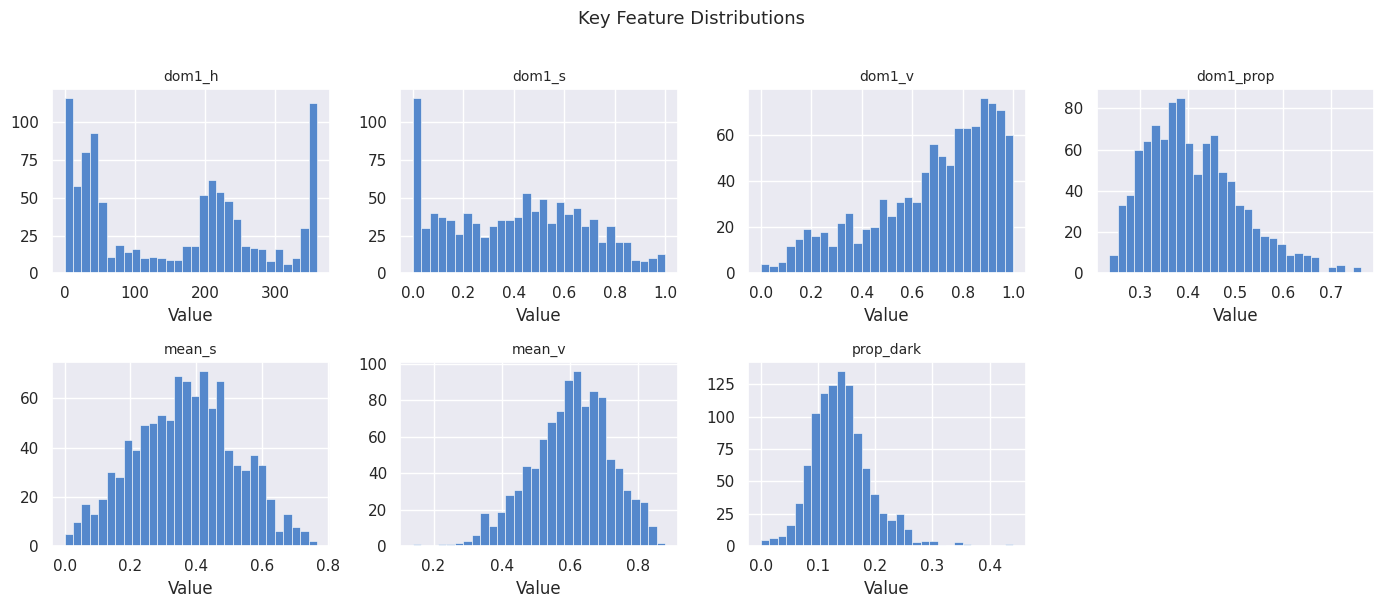

In [15]:
key_features = ["dom1_h", "dom1_s", "dom1_v", "dom1_prop", "mean_s", "mean_v", "prop_dark"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    axes[i].hist(df[feat], bins=30, color="#5588cc", edgecolor="white", linewidth=0.4)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("Value")
axes[-1].set_visible(False)
fig.suptitle("Key Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

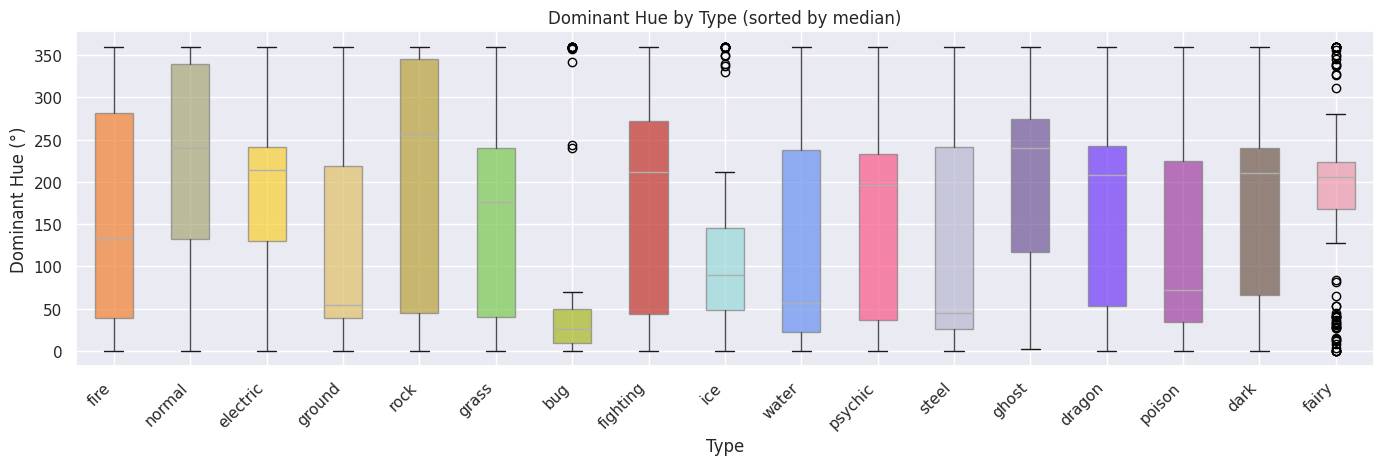

In [4]:
order = df.groupby("type1")["dom1_h"].median().sort_values().index
colors_ordered = [common.TYPE_COLORS.get(t, "#888") for t in order]
fig, ax = plt.subplots(figsize=(14, 5))
bp = df.boxplot(column="dom1_h", by="type1", ax=ax,
                positions=range(len(order)),
                boxprops=dict(color="gray"),
                patch_artist=True,
                return_type="dict")
# color each box
for patch, color in zip(bp["dom1_h"]["boxes"], colors_ordered):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_xlabel("Type")
ax.set_ylabel("Dominant Hue (°)")
ax.set_title("Dominant Hue by Type (sorted by median)")
plt.suptitle("")
plt.tight_layout()
plt.show()

Boxplots are do not quite fit the hue domain since its roundness (hue=0º is equivalent to hue=360º), but allow to see disparities through classes. Dominant hue is a strong discriminator for several types. Bug clusters around 0–40° (red/orange), Grass around 80–140° (green), and Water around 180–240° (blue). Electric shows a yellow peak around 50–70°. However, Ghost and Dark overlap heavily across the hue spectrum, since their visual identity is defined more by low saturation and value than by hue. Psychic and Fairy both cluster in the pink/magenta range (300–360°), making them difficult to distinguish from hue alone. This suggests that saturation, value, and proportion features will be critical complements to hue for these overlapping types.

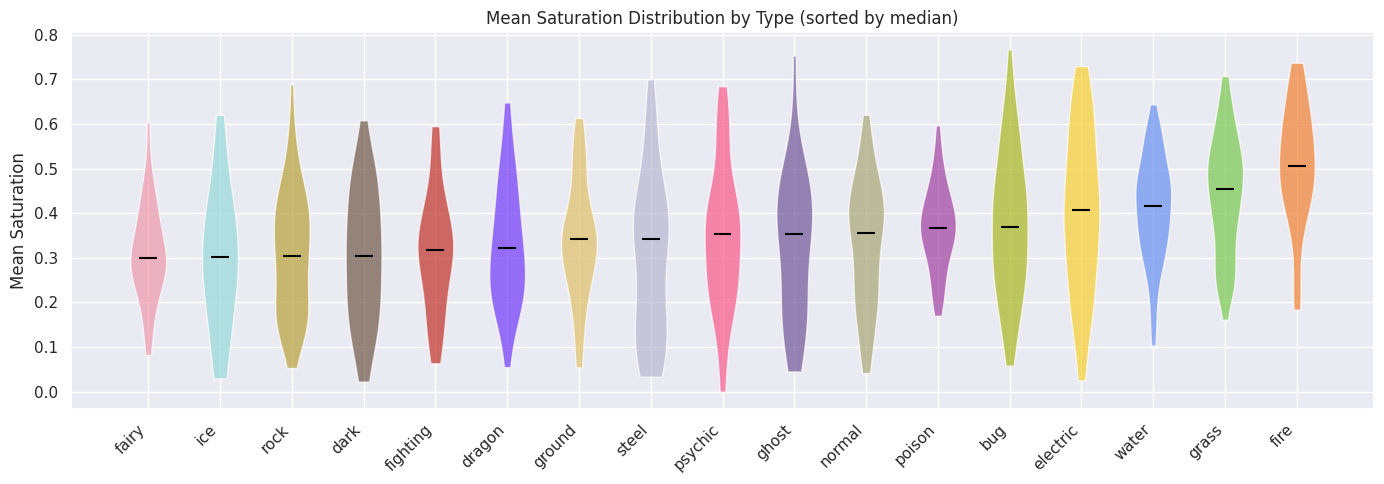

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
order_sat = df.groupby("type1")["mean_s"].median().sort_values().index
parts = ax.violinplot(
    [df[df["type1"] == t]["mean_s"].values for t in order_sat],
    positions=range(len(order_sat)),
    showmedians=True, showextrema=False,
)
for body, color in zip(parts["bodies"],
                       [common.TYPE_COLORS.get(t, "#888") for t in order_sat]):
    body.set_facecolor(color); body.set_alpha(0.7)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.5)
ax.set_xticks(range(len(order_sat)))
ax.set_xticklabels(order_sat, rotation=45, ha="right")
ax.set_ylabel("Mean Saturation")
ax.set_title("Mean Saturation Distribution by Type (sorted by median)")
plt.tight_layout(); plt.show()

Saturation is a crucial secondary discriminator. Fire, Grass and Water have high median saturation (vivid colours), while Fairy, Ice, Rock and Dark cluster at low saturation (grey/brown tones). Ghost and Bug span a wide saturation range.

## 3. Feature Correlations

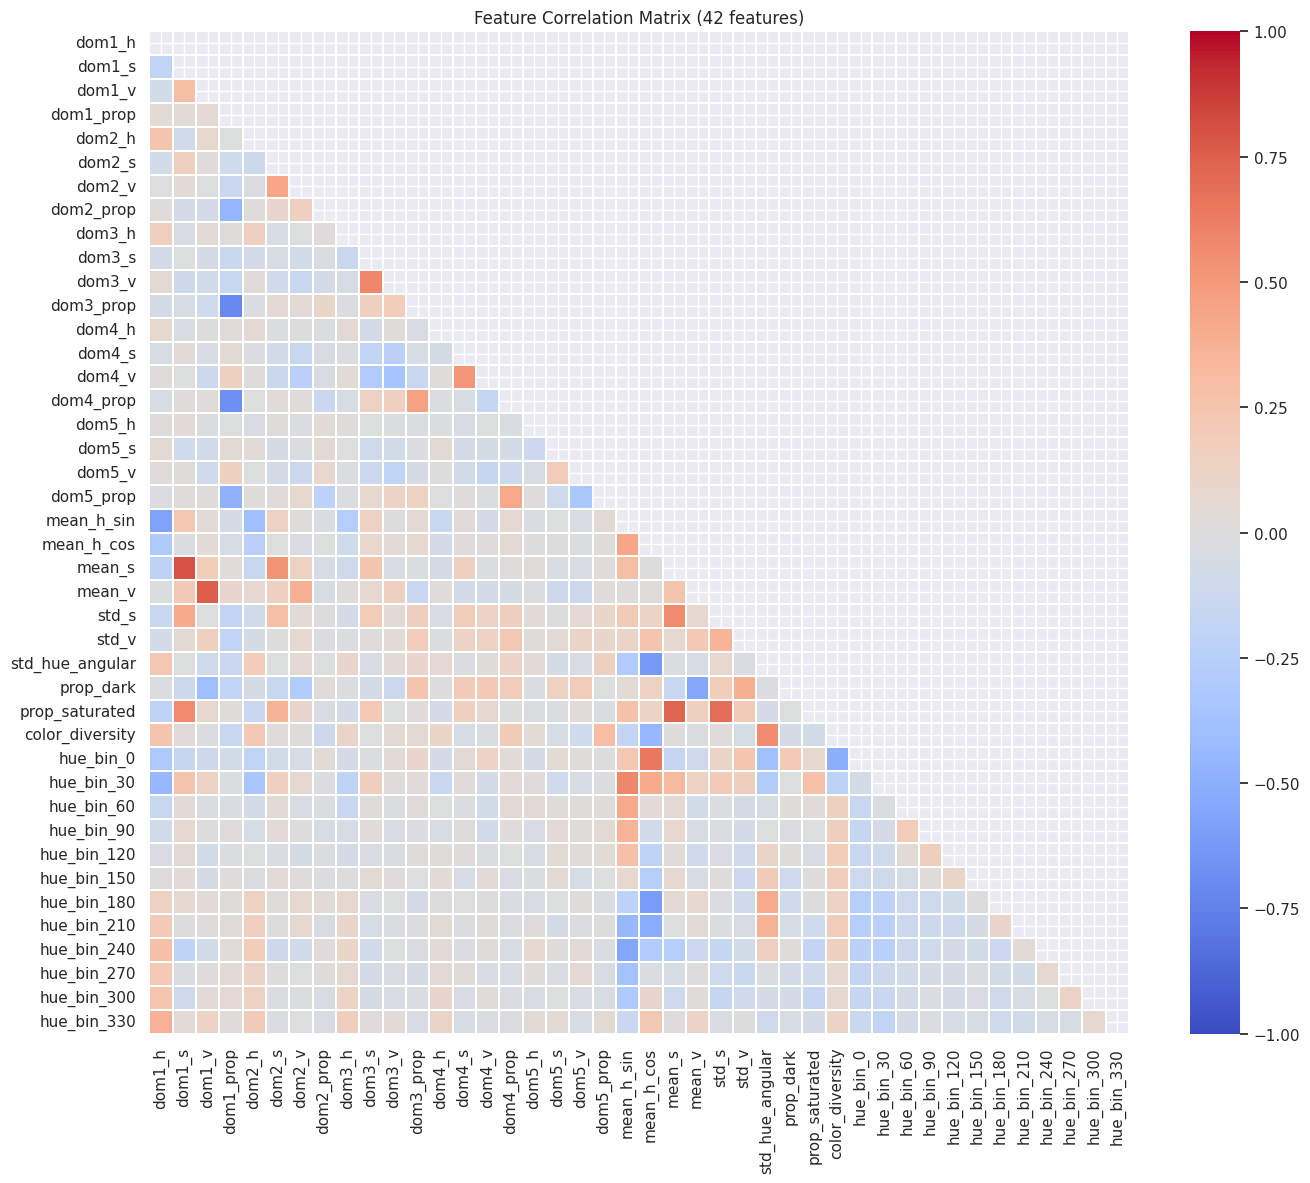

Top 10 correlated feature pairs:
mean_s           dom1_s        0.798167
mean_v           dom1_v        0.756197
prop_saturated   mean_s        0.726990
dom3_prop        dom1_prop     0.711920
prop_saturated   std_s         0.694576
dom4_prop        dom1_prop     0.675904
hue_bin_0        mean_h_cos    0.640802
std_hue_angular  mean_h_cos    0.632541
hue_bin_180      mean_h_cos    0.610211
hue_bin_30       mean_h_sin    0.580235


In [17]:
corr = df[feature_cols].corr()
# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            xticklabels=feature_cols, yticklabels=feature_cols)
ax.set_title("Feature Correlation Matrix (42 features)")
plt.tight_layout()
plt.show()

corr_abs = corr.abs()
corr_arr = corr_abs.to_numpy().copy()
np.fill_diagonal(corr_arr, 0)
corr_abs_nodiag = pd.DataFrame(corr_arr, index=corr_abs.index, columns=corr_abs.columns)
top_pairs = (corr_abs_nodiag
             .where(np.tril(np.ones(corr_abs_nodiag.shape), k=-1).astype(bool))
             .stack().nlargest(10))
print("Top 10 correlated feature pairs:")
print(top_pairs.to_string())

Several feature pairs carry overlapping information. `mean_s` and `prop_saturated` are highly correlated since both measure overall color saturation. One as a continuous mean, the other as a binary threshold proportion. Adjacent hue bins are moderately correlated due to the continuous nature of hue distributions. The K-means hue features (`dom_h`) correlate with their corresponding hue histogram bins. This redundancy is intentional: the three feature tiers (K-means, statistics, histogram) represent different views of the same color information. For Decision Trees, redundancy is less harmful; for KNN and Neural Networks, regularization or feature selection may reduce noise from near-duplicate features.

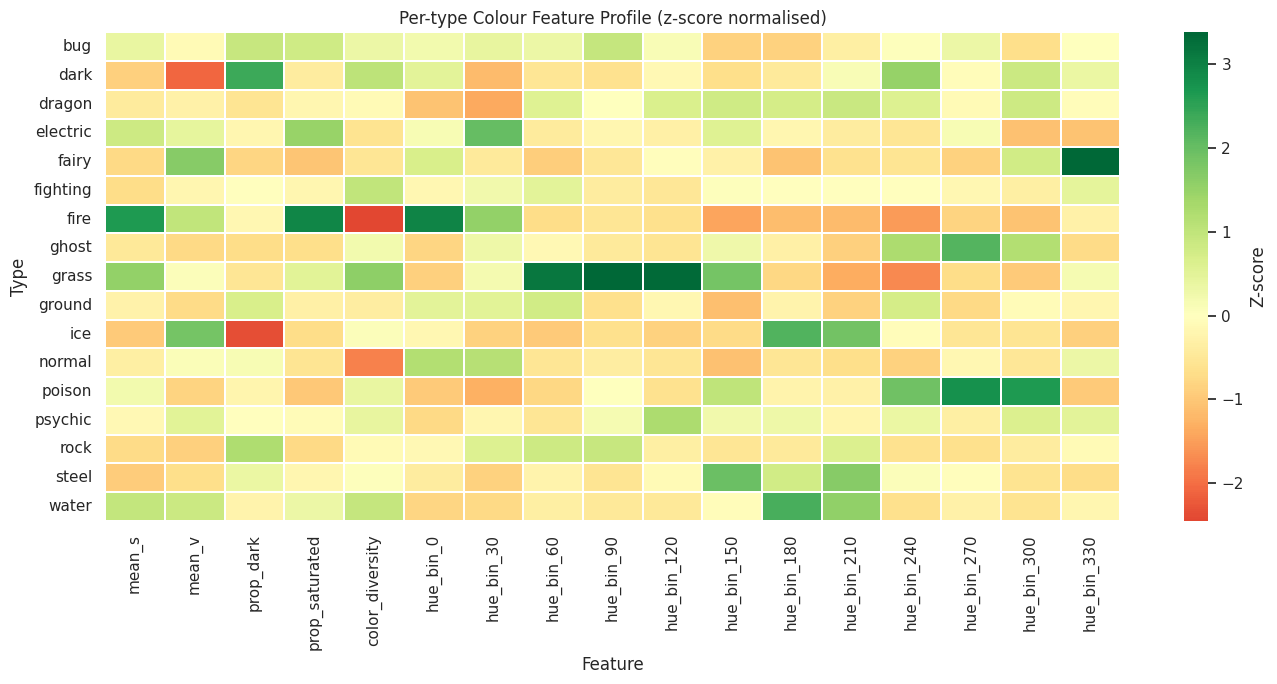

In [18]:
key_feats_profile = [
    "mean_s", "mean_v", "prop_dark", "prop_saturated", "color_diversity",
    "hue_bin_0", "hue_bin_30", "hue_bin_60", "hue_bin_90", "hue_bin_120",
    "hue_bin_150", "hue_bin_180", "hue_bin_210", "hue_bin_240",
    "hue_bin_270", "hue_bin_300", "hue_bin_330",
]
type_profile = df.groupby("type1")[key_feats_profile].mean()
# Z-score per column (across types) to make all features comparable
type_profile_norm = type_profile.copy()
for col in key_feats_profile:
    std_ = type_profile[col].std()
    if std_ > 0:
        type_profile_norm[col] = (type_profile[col] - type_profile[col].mean()) / std_

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(type_profile_norm, cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.3, cbar_kws={"label": "Z-score"})
ax.set_title("Per-type Colour Feature Profile (z-score normalised)")
ax.set_xlabel("Feature"); ax.set_ylabel("Type")
plt.tight_layout(); plt.show()

The colour fingerprint heatmap is the EDA's most actionable insight for modelling. Fire dominates `hue_bin_0` (red); Water dominates `hue_bin_180-210` (blue); Grass dominates `hue_bin_60-120` (green); Electric has high `hue_bin_30` (yellow) and `prop_saturated`; Dark show high `prop_dark`; Ice has low `prop_dark` (bright and shiny). Types with few distinctive features (Rock) or overlapping ones (Poison and Ghost via purple hue) will be the hardest to classify. This visual motivates examining feature importance in the model notebooks.

## 4. Dimensionality Reduction Visualization

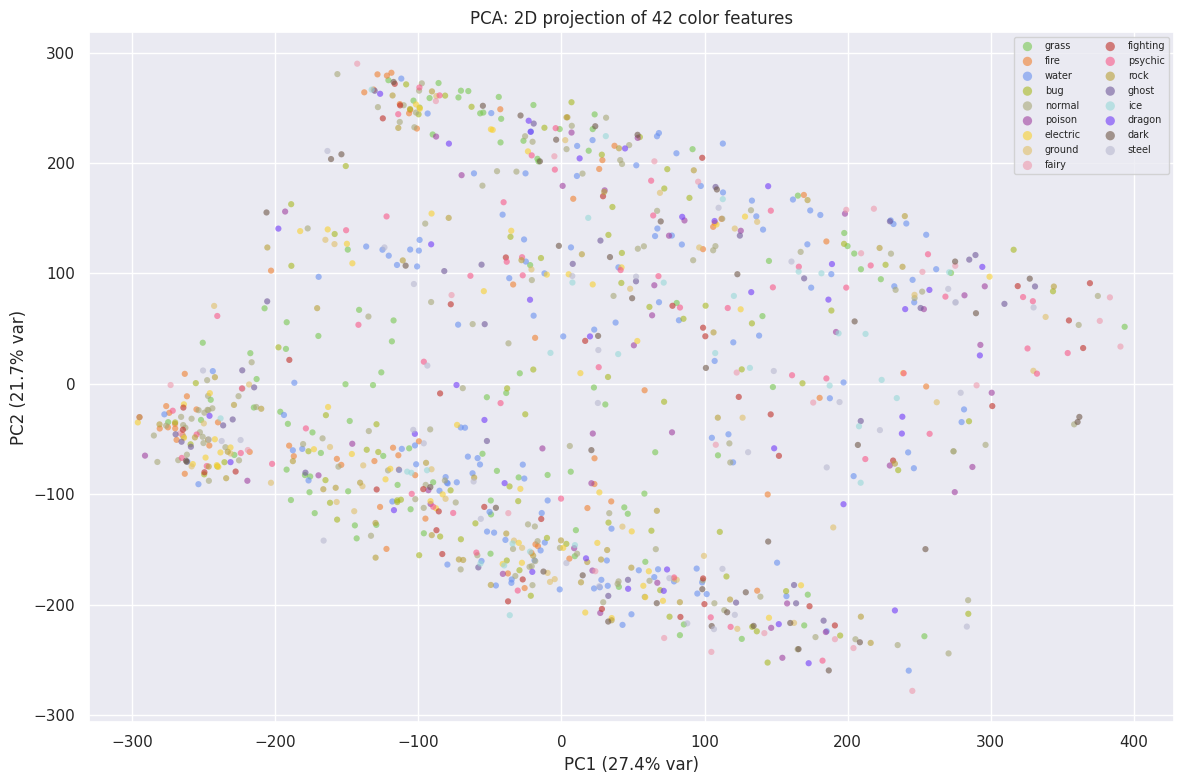

Cumulative explained variance (2 PCs): 49.1%


In [19]:
X = df[feature_cols].values
y = df["type1"].values
y_int = df["type1_encoded"].values

pca = PCA(n_components=2, random_state=common.RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
for type_name in df["type1"].unique():
    mask = y == type_name
    color = common.TYPE_COLORS.get(type_name, "#888888")
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=type_name, alpha=0.6, s=20, edgecolors="none")
ax.legend(loc="upper right", fontsize=7, ncol=2, markerscale=1.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA: 2D projection of 42 color features")
plt.tight_layout()
plt.show()
print(f"Cumulative explained variance (2 PCs): {pca.explained_variance_ratio_.sum()*100:.1f}%")

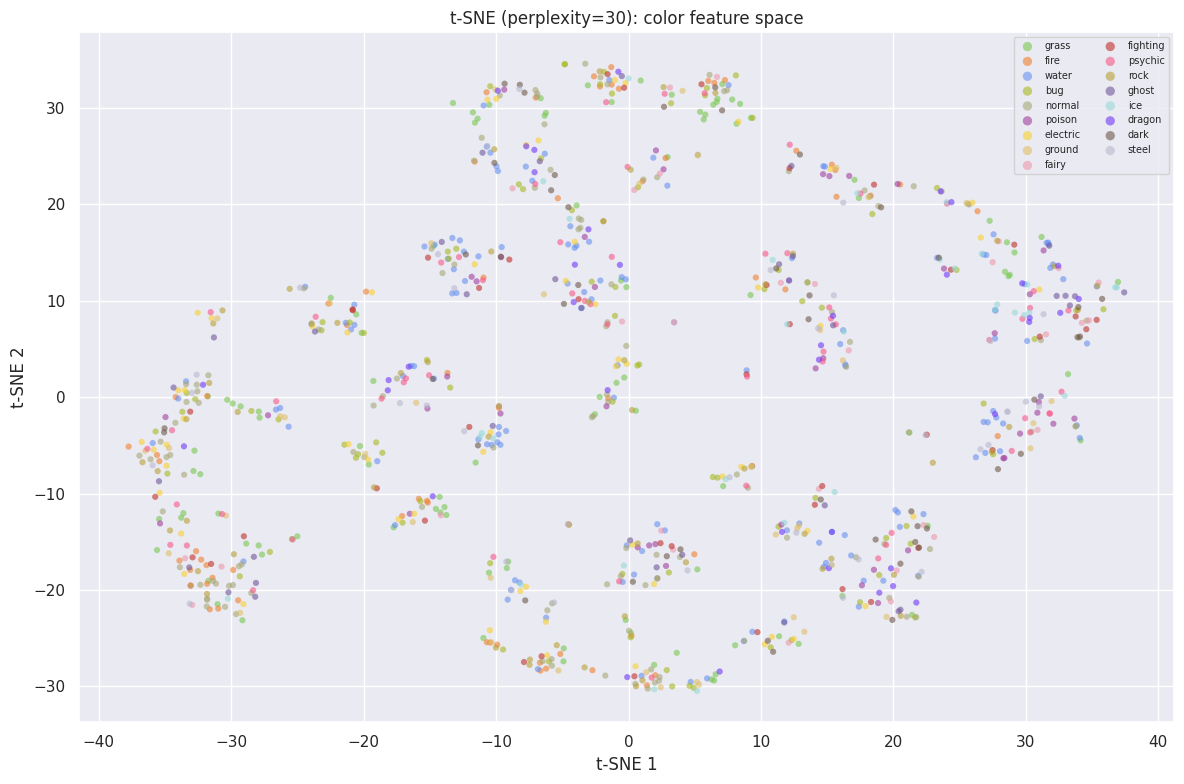

In [20]:
tsne = TSNE(n_components=2, perplexity=30, random_state=common.RANDOM_STATE)
X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
for type_name in df["type1"].unique():
    mask = y == type_name
    color = common.TYPE_COLORS.get(type_name, "#888888")
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=type_name, alpha=0.6, s=20, edgecolors="none")
ax.legend(loc="upper right", fontsize=7, ncol=2, markerscale=1.5)
ax.set_title("t-SNE (perplexity=30): color feature space")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

PCA retains approximately 49.1% of total variance in 2 components, indicating that the 42-feature color space has substantial intrinsic dimensionality that cannot be collapsed linearly but still a good result. The PCA scatter shows most types overlap heavily. t-SNE, which preserves local neighborhood structure, reveals clearer partial clustering: Water forms loose but identifiable clusters, Electric tends to appear in a distinct region, while Normal, Psychic, and Ghost scatter broadly across the embedding. This confirms that color features provide genuine discriminative signal for several types but cannot perfectly separate all 17 classes.